<a href="https://colab.research.google.com/github/Phalguni-dhabale/MV-LAB/blob/main/MV_P8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [2]:
!pip install ultralytics opencv-python matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 5.0 MB/s eta 0:00:00


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.


In [4]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

In [5]:
from google.colab import files

uploaded = files.upload()

Saving packages.jpg to packages.jpg



image 1/1 /content/packages.jpg: 640x640 1 refrigerator, 444.8ms
Speed: 62.4ms preprocess, 444.8ms inference, 35.7ms postprocess per image at shape (1, 3, 640, 640)


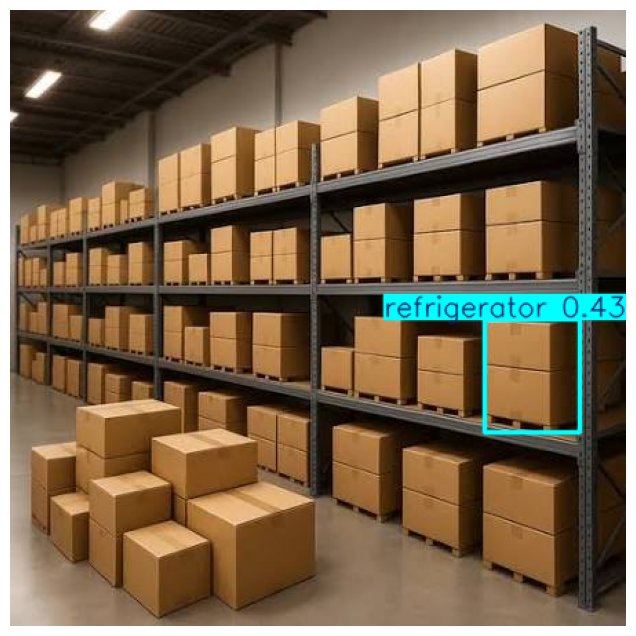

In [6]:
image_path = "packages.jpg"

results = model(image_path)

result = results[0]

annotated_image = result.plot()

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [7]:
for box in result.boxes:
    x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
    confidence = float(box.conf[0])
    class_id = int(box.cls[0])

    class_name = model.names[class_id]

    print("Object:", class_name)
    print("Confidence:", round(confidence, 2))
    print("Location:",
          f"({int(x1)}, {int(y1)}) to ({int(x2)}, {int(y2)})")
    print("-" * 40)

Object: refrigerator
Confidence: 0.43
Location: (344, 224) to (413, 306)
----------------------------------------


In [8]:
uploaded = files.upload()

Saving warehouse.jpg to warehouse.jpg


In [12]:
!pip install -q ultralytics

In [13]:
from ultralytics import YOLO
import cv2
import os

In [14]:
model = YOLO("yolov8n.pt")
print("YOLO model loaded successfully!")

YOLO model loaded successfully!



0: 640x640 (no detections), 344.0ms
Speed: 12.2ms preprocess, 344.0ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)


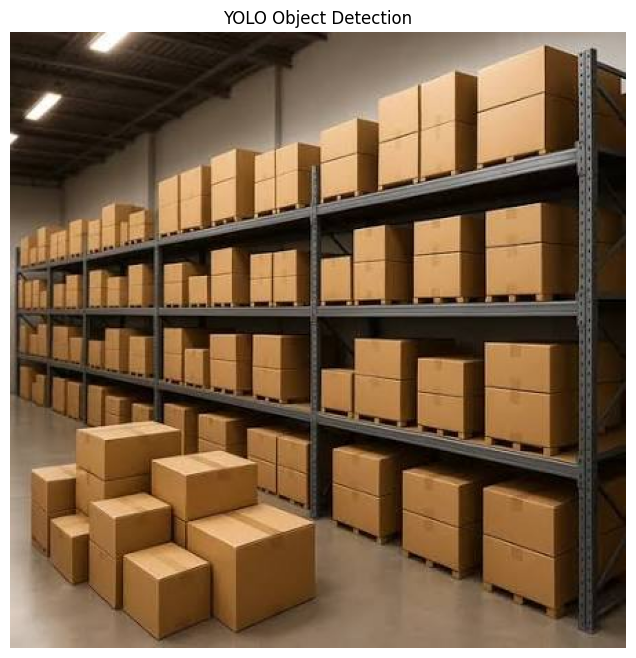

Detected Objects:
-------------------------
Performance
-------------------------
Processing Time: 0.3984 seconds
FPS: 2.51
Total Objects: 0


In [15]:
import cv2
import matplotlib.pyplot as plt
import time
from ultralytics import YOLO

# Load YOLO model
model = YOLO("yolov8n.pt")

# Load image
image = cv2.imread("packages.jpg")

# Start timer
start_time = time.time()

# Object detection
results = model(image, conf=0.5)

# End timer
end_time = time.time()

# Processing time
processing_time = end_time - start_time

# Get result
result = results[0]

# Display detected objects
annotated_image = result.plot()

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("YOLO Object Detection")
plt.show()

# Print object information
print("Detected Objects:")
print("-------------------------")

for box in result.boxes:

    x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()

    confidence = float(box.conf[0])

    class_id = int(box.cls[0])

    class_name = model.names[class_id]

    print("Object:", class_name)
    print("Confidence:", round(confidence, 2))

    print(
        "Bounding Box:",
        (int(x1), int(y1), int(x2), int(y2))
    )

    print()

# Performance
print("Performance")
print("-------------------------")
print("Processing Time:",
      round(processing_time, 4), "seconds")

print("FPS:",
      round(1 / processing_time, 2))

print("Total Objects:",
      len(result.boxes))